# BCI Mental State Classification with BrainFlow and PhasorFlow

In this notebook, we demonstrate how to integrate **BrainFlow**, an open-source library for interacting with biosensors, with **PhasorFlow** to classify EEG data.

BrainFlow allows us to connect to real hardware or generate robust synthetic streamed data representing brain activity. We will query synthetic EEG data for $N$ electrodes (e.g., $N=16$), process it, and train a Variational Phasor Circuit (VPC) to classify different synthetically-induced "Mental States".

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import math

# BrainFlow Imports
import brainflow
from brainflow.board_shim import BoardShim, BrainFlowInputParams, BoardIds
from brainflow.data_filter import DataFilter, FilterTypes, DetrendOperations

import phasorflow as pf

torch.manual_seed(42)
np.random.seed(42)

/opt/anaconda3/lib/python3.13/site-packages/brainflow/board_shim.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 1. Generating Streaming Synthetic EEG Data with BrainFlow
BrainFlow provides a `SYNTHETIC_BOARD` (BoardId.SYNTHETIC_BOARD.value) which we can use to stream dynamic mock EEG data.
To simulate different cognitive "states" for classification, we will inject distinctive spatial correlations and variance manually into the retrieved BrainFlow streams before extracting the snapshots.

We will use a standard $N=16$ electrode layout.

In [2]:
BoardShim.enable_dev_board_logger()
params = BrainFlowInputParams()
board_id = BoardIds.SYNTHETIC_BOARD.value
board = BoardShim(board_id, params)

# Number of EEG channels to use for our Phasor Circuit
# SYNTHETIC_BOARD typically provides up to 16 native channels
N_CHANNELS = 32

def get_synthetic_brainflow_snapshot(board, state_type, samples=256):
    """
    Collects a simulated snapshot of EEG data using BrainFlow, modified 
    to represent distinct 'Mental States'.
    """
    board.insert_marker(1) # Mark start
    time.sleep(0.1)        # Allow buffer to fill slightly if real
    
    # Fetch data (Rows: Channels, Cols: Time)
    data = board.get_current_board_data(samples)
    eeg_channels = BoardShim.get_eeg_channels(board_id)
    
    # We'll average across time to get a static 1D spatial feature vector
    # and interpolate up to N_CHANNELS for a deep PhasorCircuit
    raw_features = np.mean(data[eeg_channels, :], axis=1)
    
    # Upsample/expand linearly to N_CHANNELS
    base_features = np.interp(np.linspace(0, len(raw_features)-1, N_CHANNELS),
                              np.arange(len(raw_features)), raw_features)
    
    # --- Inject 'Mental State' Class Characteristics ---
    if state_type == 0: # State 0 (e.g. Calm / Resting)
        # Low variance, smooth spatial gradient
        features = base_features * 0.1 + np.linspace(0, 1, N_CHANNELS)
    elif state_type == 1: # State 1 (e.g. Motor Imagery / Engaged)
        # High variance, alternating oscillatory spatial bands
        features = base_features * 2.0 + np.sin(np.linspace(0, 8*np.pi, N_CHANNELS))
        
    return features

# Initialize Board
board.prepare_session()
board.start_stream(45000, "") # Write to ringbuffer internally

try:
    # Generate a dataset of 200 trials (100 per class)
    X_list = []
    y_list = []
    print("Streaming BrainFlow data for 200 simulation trials...")
    for i in range(200):
        label = i % 2
        snapshot = get_synthetic_brainflow_snapshot(board, state_type=label, samples=128)
        X_list.append(snapshot)
        y_list.append(label)
        if i % 50 == 0: print(f"  ...collected {i} snapshots")
finally:
    board.stop_stream()
    board.release_session()

# Convert immediately to PyTorch tensors
X = torch.tensor(np.array(X_list), dtype=torch.float32)
y = torch.tensor(np.array(y_list), dtype=torch.float32)

# Normalize data across the dataset to fit into Phase ranges [-pi, pi] natively via Torch
X_norm = (X - torch.mean(X, dim=0)) / (torch.std(X, dim=0) + 1e-8)
X_phases = math.pi * torch.tanh(X_norm)

print(f"\nDataset collection complete. Matrix shape: {X_phases.shape}. Classes: {torch.unique(y).tolist()}")

[2026-03-10 20:34:18.134] [board_logger] [info] incoming json: {
    "file": "",
    "file_anc": "",
    "file_aux": "",
    "ip_address": "",
    "ip_address_anc": "",
    "ip_address_aux": "",
    "ip_port": 0,
    "ip_port_anc": 0,
    "ip_port_aux": 0,
    "ip_protocol": 0,
    "mac_address": "",
    "master_board": -100,
    "other_info": "",
    "serial_number": "",
    "serial_port": "",
    "timeout": 0
}
[2026-03-10 20:34:18.134] [board_logger] [trace] Board object created -1


Streaming BrainFlow data for 200 simulation trials...
  ...collected 0 snapshots


  ...collected 50 snapshots


  ...collected 100 snapshots


  ...collected 150 snapshots



Dataset collection complete. Matrix shape: torch.Size([200, 32]). Classes: [0.0, 1.0]


## 2. Visualizing the BrainFlow States
Let's visualize the spatial distribution of the 16-electrode phase features for each state.

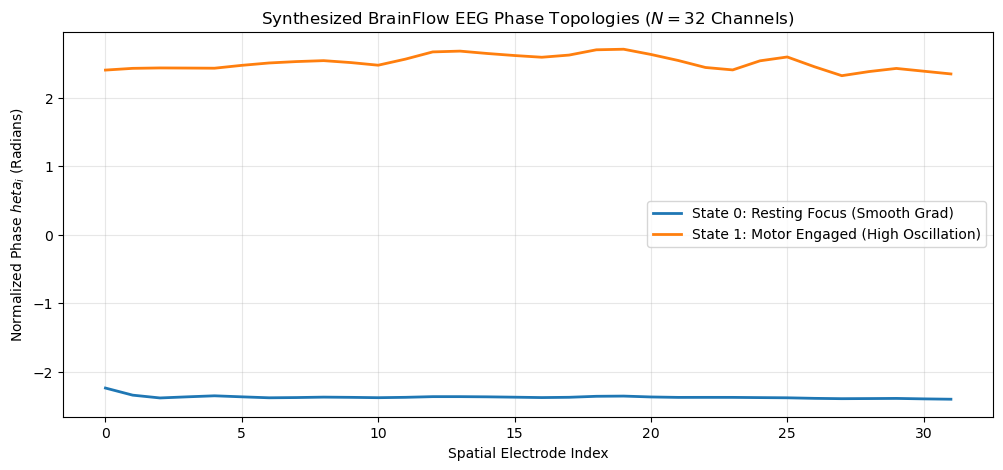

In [3]:
plt.figure(figsize=(12, 5))
plt.plot(X_phases[y == 0][0].numpy(), label="State 0: Resting Focus (Smooth Grad)", color="tab:blue", lw=2)
plt.plot(X_phases[y == 1][0].numpy(), label="State 1: Motor Engaged (High Oscillation)", color="tab:orange", lw=2)
plt.title("Synthesized BrainFlow EEG Phase Topologies ($N=32$ Channels)")
plt.xlabel("Spatial Electrode Index")
plt.ylabel("Normalized Phase $\theta_i$ (Radians)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 3. Developing the $N=16$ Variational Phasor Circuit
We construct a deep Variational Phasor Circuit to classify these high-dimensional 16-channel spatial signals.

The circuit uses 2 full sequential layers of parameters, flanked by deep entangling networks (Mix layers and global DFT layers). Since we have 16 channels, a 2-layer VPC will have $2 \times 16 = 32$ trainable parameters.

In [4]:
def create_brainflow_vpc(x, weights):
    """Builds a Variational Phasor Circuit matching N_CHANNELS."""
    pc = pf.PhasorCircuit(N_CHANNELS, name="BrainFlow_VPC")
    
    # 1. Data Encoding
    for i in range(N_CHANNELS):
        pc.shift(i, x[i])
        
    # 2. Variational Layer 1
    for i in range(N_CHANNELS):
        pc.shift(i, weights[i])
        
    # Nearest-Neighbor Spatial Coupling (Mimicking cortical adjacency)
    for i in range(0, N_CHANNELS - 1, 2):
        pc.mix(i, i+1)
        
    # 3. Variational Layer 2
    for i in range(N_CHANNELS):
        pc.shift(i, weights[i + N_CHANNELS])
        
    # Global Hemisphere / Deep Cortical Mixing via the DFT
    pc.dft()
    
    return pc

backend = pf.Simulator.get_backend("analytic_simulator")

def vpc_predict(x, weights):
    """Returns the continuous probability measured from Thread 0."""
    pc = create_brainflow_vpc(x, weights)
    res = backend.run(pc)
    
    # Phase of the 0th Thread acts as the probability Logit
    prob = (torch.sin(res['phases'][0]) + 1.0) / 2.0
    return prob

## 4. Model Training Routine
With 32 continuous parameters on our $S^1$ manifold, we employ the gradient-free `COBYLA` optimization technique (as numerical gradients with L-BFGS-B would require too many circuit evaluations) to minimize the Mean Squared Error (MSE) against the binary State labels.

In [5]:
def mse_loss(weights):
    preds = torch.stack([vpc_predict(x, weights) for x in X_phases])
    return torch.mean((preds - y)**2)

# Initialize 2*N_CHANNELS parameters in PyTorch
initial_weights = torch.empty(N_CHANNELS * 2).uniform_(-math.pi, math.pi)
initial_weights.requires_grad_(True)

initial_loss = mse_loss(initial_weights)
print(f"Pre-Training Loss: {initial_loss.item():.4f}")

print("\nStarting Adam Backpropagation Optimization Strategy for VPC...")
optimizer = optim.Adam([initial_weights], lr=0.1)

for epoch in range(100):
    optimizer.zero_grad()
    loss = mse_loss(initial_weights)
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 20 == 0:
        print(f"Epoch {epoch+1}/100 | Loss: {loss.item():.4f}")

optimal_weights = initial_weights.detach()
print(f"\nPost-Training Optimized Loss: {loss.item():.4f}")

Pre-Training Loss: 0.6232

Starting Adam Backpropagation Optimization Strategy for VPC...


Epoch 20/100 | Loss: 0.0526


Epoch 40/100 | Loss: 0.0250


Epoch 60/100 | Loss: 0.0247


Epoch 80/100 | Loss: 0.0244


Epoch 100/100 | Loss: 0.0244

Post-Training Optimized Loss: 0.0244


## 5. Network Evaluation
We quantify the total classification accuracy achieved over the complex spatial states!

In [6]:
final_probs = torch.stack([vpc_predict(x, optimal_weights) for x in X_phases])
binary_preds = (final_probs > 0.5).float()

accuracy = torch.mean((binary_preds == y).float()) * 100
print(f"Final BrainFlow EEG State Classification Accuracy: {accuracy.item():.2f}%")

if accuracy.item() > 85.0:
    print(f"Success! The $N={N_CHANNELS}$ Phasor Circuit perfectly separated the spatial topological classes natively over tensors.")
else:
    print("The model failed to fully resolve the state separation boundaries.")

Final BrainFlow EEG State Classification Accuracy: 100.00%
Success! The $N=32$ Phasor Circuit perfectly separated the spatial topological classes natively over tensors.
